# Out-of-Sample Deployment Decision

The previous model-comparison notebook identified the best model for each product family based on validation-set MAPE. Several machine learning models achieved stronger validation accuracy than traditional statistical models.

However, out-of-sample forecasting requires more than validation accuracy. The final forecast must be reproducible, stable, and reliable because it becomes an input for downstream inventory optimization.

During the test-forecasting stage, the saved machine learning model artifacts showed unreliable inference behavior. In particular, the deployed XGBoost artifacts produced forecast volumes that were not reliable enough for the final out-of-sample pipeline. Because of this deployment issue, I disabled the machine learning route for the test period and used the best traditional statistical model for each product family.

This decision should be interpreted as a deployment-risk control decision, not as a general rejection of machine learning models. The validation results still show that ML models can capture useful nonlinear patterns. However, the final inventory optimization pipeline requires forecast inputs that are stable, reproducible, and operationally defensible.

Therefore, the final test-period forecasts are generated using the traditional statistical fallback route.

## Notebook Role in the Forecasting Pipeline

| Item | Description |
|---|---|
| Notebook role | Final out-of-sample forecasting |
| Main question | Which model route is reliable enough for test-period forecast generation? |
| Main output | Weekly and daily test-period forecasts |
| Final deployment logic | Use traditional fallback because ML artifact/inference behavior was unreliable |

# Imports and Data Loading

In [107]:
import os
import numpy as np # mathematic calculations
import pandas as pd # exploratory data analysis
import scipy.stats as stats # statistics
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # data visualization
import datetime as dt # date data manipulation
import time # training and predicting time recording
import ast
import joblib

# Import Time Series Analysis libraries
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.api import ARIMA, SARIMAX

# Libraries for Machine Learning Models
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_log_error
import category_encoders as ce

# Neural Network
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from keras.models import Model
import keras_tuner as kt
from scikeras.wrappers import KerasRegressor
from scipy.stats import loguniform, randint, uniform

In [108]:
import numpy as np
import pandas as pd
import joblib
import os

# Define Paths
MAIN = '/Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System'
DATA = os.path.join(MAIN, 'data')
MODELS = os.path.join(MAIN, 'models')
RESULTS = os.path.join(MAIN, 'results')

# Load necessary datasets
final_test_df = pd.read_csv(os.path.join(DATA, 'final_test_df.csv'), parse_dates=['date'])
final_train_df = pd.read_csv(os.path.join(DATA, 'final_train_df.csv'), parse_dates=['date'])
weekly_features = pd.read_csv(os.path.join(DATA, 'weekly_features.csv'))

# Load Routing Logic
routing_df = pd.read_csv(os.path.join(RESULTS, 'ml_trad_model_comparison.csv'))
best_trad_models = pd.read_csv(os.path.join(MODELS, 'best_models_per_family.csv'))

# Phase 1 & 2 - Feature Engineering Functions

In [ ]:
# ==========================================
# TEST SET FEATURE PIPELINE (PATCHED)
# ==========================================
def process_test_data(test_df):
    """Aggregates the daily test data into weekly exogenous features."""
    # 1. Collapse Test Data to Weekly
    date_features = final_test_df[['date', 'is_holiday', 'days_since_earthquake', 'oil_price']].drop_duplicates()
    weekly_date_features = date_features.groupby(pd.Grouper(key='date', freq='W-SUN')).agg(
        holiday_count=('is_holiday', 'sum'),
        is_holiday_week=('is_holiday', 'max'),
        max_days_since_earthquake=('days_since_earthquake', 'max'),
        avg_oil_price=('oil_price', 'mean')
    ).reset_index()

    weekly_promo = final_test_df.groupby(['family', pd.Grouper(key='date', freq='W-SUN')]).agg(
        onpromotion=('onpromotion', 'sum')
    ).reset_index()

    weekly_test_df = pd.merge(weekly_promo, weekly_date_features, on='date', how='left')

    # Add Calendar Features
    weekly_test_df['month'] = weekly_test_df['date'].dt.month
    weekly_test_df['quarter'] = weekly_test_df['date'].dt.quarter
    weekly_test_df['year'] = weekly_test_df['date'].dt.year

    # PATCH: Dynamically calculate the total_week_number to continue from the Training Set
    max_train_week = weekly_features['total_week_number'].max()
    unique_test_weeks = weekly_test_df['date'].sort_values().unique()

    week_mapping = {date: max_train_week + i + 1 for i, date in enumerate(unique_test_weeks)}
    weekly_test_df['total_week_number'] = weekly_test_df['date'].map(week_mapping)

    print("Test Set Features Engineered Correctly!")
    print("Columns Available:", list(weekly_test_df.columns))
    
    return weekly_test_df

def extract_current_state_lags(weekly_features_df):
    """
    Extracts the final chronological row for each family from the training features.
    This serves as the static historical lag state.
    
    Args:
        weekly_features_df (pd.DataFrame): The weekly training features dataset.
        
    Returns:
        pd.DataFrame: A dataframe containing only the last known row per family.
    """
    # Sort chronologically to ensure the last row is the most recent
    weekly_features_df = weekly_features_df.sort_values(by=['family', 'date'])
    
    # Grab the very last row for each family
    current_state = weekly_features_df.groupby('family').tail(1).copy()
    
    # We drop 'date' and 'sales' because these belong to the past training week, not the future
    current_state = current_state.drop(columns=['date', 'sales'])
    
    return current_state

# Execute Feature Engineering
weekly_test_exog = process_test_data(final_test_df)
static_lags = extract_current_state_lags(weekly_features)

Test Set Features Engineered Correctly!
Columns Available: ['family', 'date', 'onpromotion', 'holiday_count', 'is_holiday_week', 'max_days_since_earthquake', 'avg_oil_price', 'month', 'quarter', 'year', 'total_week_number']


In [110]:
weekly_test_exog

,family,date,onpromotion,holiday_count,is_holiday_week,max_days_since_earthquake,avg_oil_price,month,quarter,year
0,AUTOMOTIVE,2017-08-20,1,5,True,0,47.928000,8,3,2017
1,AUTOMOTIVE,2017-08-27,2,7,True,0,47.668571,8,3,2017
2,AUTOMOTIVE,2017-09-03,16,4,True,0,46.520000,9,3,2017
3,BABY CARE,2017-08-20,1,5,True,0,47.928000,8,3,2017
4,BABY CARE,2017-08-27,0,7,True,0,47.668571,8,3,2017
...,...,...,...,...,...,...,...,...,...,...
94,SCHOOL AND OFFICE SUPPLIES,2017-08-27,1018,7,True,0,47.668571,8,3,2017
95,SCHOOL AND OFFICE SUPPLIES,2017-09-03,613,4,True,0,46.520000,9,3,2017
96,SEAFOOD,2017-08-20,182,5,True,0,47.928000,8,3,2017
97,SEAFOOD,2017-08-27,235,7,True,0,47.668571,8,3,2017


# Test Dataset Processing & Feature Engineering

In [ ]:
# def process_test_data(test_df):
#     """Aggregates the daily test data into weekly exogenous features."""
#     date_features = test_df[['date', 'is_holiday', 'days_since_earthquake', 'oil_price']].drop_duplicates()
    
#     weekly_date_features = date_features.groupby(pd.Grouper(key='date', freq='W-SUN')).agg(
#         holiday_count=('is_holiday', 'sum'),
#         is_holiday_week=('is_holiday', 'max'),
#         max_days_since_earthquake=('days_since_earthquake', 'max'),
#         avg_oil_price=('oil_price', 'mean')
#     ).reset_index()

#     weekly_promo = test_df.groupby(['family', pd.Grouper(key='date', freq='W-SUN')]).agg(
#         onpromotion=('onpromotion', 'sum')
#     ).reset_index()

#     weekly_test_df = pd.merge(weekly_promo, weekly_date_features, on='date', how='left')

#     weekly_test_df['month'] = weekly_test_df['date'].dt.month
#     weekly_test_df['quarter'] = weekly_test_df['date'].dt.quarter
#     weekly_test_df['year'] = weekly_test_df['date'].dt.year
    
#     return weekly_test_df

# def extract_current_state_lags(weekly_features_df):
#     """Extracts the final chronological row of the training features for each family."""
#     weekly_features_df = weekly_features_df.sort_values(by=['family', 'date'])
#     current_state = weekly_features_df.groupby('family').tail(1).copy()
#     current_state = current_state.drop(columns=['date', 'sales'])
    
#     return current_state

# # Execute Feature Engineering
# weekly_test_exog = process_test_data(final_test_df)
# static_lags = extract_current_state_lags(weekly_features)

# display(weekly_test_exog.head())

In [112]:
display(weekly_features.head())

,family,date,sales,onpromotion,holiday_count,is_holiday_week,max_days_since_earthquake,avg_oil_price,total_week_number,month,...,year,lag_1,lag_2,lag_3,lag_4,lag_12,lag_13,rolling_mean_4,rolling_mean_8,rolling_std_4
0,AUTOMOTIVE,2013-01-06,1287.0,0,6,True,0,93.101667,1,1,...,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AUTOMOTIVE,2013-01-13,1514.0,0,7,True,0,93.442857,2,1,...,2013,1287.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AUTOMOTIVE,2013-01-20,1511.0,0,7,True,0,94.875714,3,1,...,2013,1514.0,1287.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AUTOMOTIVE,2013-01-27,1517.0,0,7,True,0,95.365714,4,1,...,2013,1511.0,1514.0,1287.0,NaN,NaN,NaN,NaN,NaN,NaN
4,AUTOMOTIVE,2013-02-03,1807.0,0,7,True,0,97.368571,5,2,...,2013,1517.0,1511.0,1514.0,1287.0,NaN,NaN,1457.25,NaN,113.526429


In [113]:
weekly_features.columns

Index(['family', 'date', 'sales', 'onpromotion', 'holiday_count',
       'is_holiday_week', 'max_days_since_earthquake', 'avg_oil_price',
       'total_week_number', 'month', 'quarter', 'year', 'lag_1', 'lag_2',
       'lag_3', 'lag_4', 'lag_12', 'lag_13', 'rolling_mean_4',
       'rolling_mean_8', 'rolling_std_4'],
      dtype='object')

# Phase 3 - Hybrid Forecasting Loop

In [114]:
routing_df

,family,MAE_Trad,RMSE_Trad,MAPE_Trad,MAE_ML,RMSE_ML,MAPE_ML,MAE_Better_%,RMSE_Better_%,MAPE_Better_%
0,BEVERAGES,99826.201427,152188.473698,11.136889,51791.929607,75655.240061,6.015036,48.117900,50.288456,45.989977
1,BREAD/BAKERY,9803.048873,13424.061684,5.422537,12967.753363,17573.802064,6.951399,-32.282859,-30.912703,-28.194570
2,CLEANING,31293.924810,42438.932717,7.443776,25180.685328,32721.630671,5.945446,19.534908,22.897140,20.128632
3,DAIRY,54624.627119,69132.836339,19.387999,17750.994144,24059.748887,6.282125,67.503679,65.197799,67.597869
4,DELI,6457.852029,8922.494678,6.275877,8091.619031,10821.457284,7.842143,-25.298923,-21.282866,-24.956917
5,GROCERY I,118905.065587,186807.245486,7.641640,39235.114856,52030.714792,2.764196,67.002991,72.147379,63.827193
6,MEATS,9798.164562,15795.551037,8.206676,9288.224263,13112.913658,6.985258,5.204447,16.983500,14.883218
7,PERSONAL CARE,10336.788545,15163.890491,9.936365,10722.992485,14121.195130,10.303720,-3.736208,6.876173,-3.697085
8,POULTRY,10030.733255,13977.379083,7.620006,10104.397450,13440.144851,7.203036,-0.734385,3.843598,5.472035
9,PRODUCE,72824.029502,111994.058712,852.225288,36895.932051,55337.502563,455.155315,49.335498,50.588894,46.592137


In [ ]:
def generate_hybrid_forecasts(weekly_test_exog, static_lags, routing_df, best_trad_models, weekly_features):
    all_forecasts = []
    
    forecast_families = routing_df['family'].unique()
    
    for family in forecast_families:
        family_route = routing_df[routing_df['family'] == family].iloc[0]
        mape_better = family_route['MAPE_Better_%']
        
        best_mape = min(family_route['MAPE_Trad'], family_route['MAPE_ML'])
        is_broken_model = best_mape > 50.0
        
        # # Edit 1: Manual overrides for families that produce mathematically poor or unrealistic continuations
        # force_seasonal_naive = False
        # if family in ['BEVERAGES', 'PRODUCE']:
        #     force_seasonal_naive = True
        #     use_ml = False
        #     is_broken_model = True
        # else:
        #     use_ml = (mape_better > 0) and not is_broken_model

        # # Edit 2: Manual overrides for families that produce mathematically poor or unrealistic continuations
        # force_seasonal_naive = False
        # if family in ['BEVERAGES', 'PRODUCE']:
        #     force_seasonal_naive = True
            
        # # DISABLE MACHINE LEARNING ENTIRELY
        # # The XGBoost models saved on disk are corrupted/shallow and output fractions of true volume.
        # # I route 100% of families to the highly robust Traditional/Baseline pipeline.
        # use_ml = False
        # is_broken_model = False # Not needed since I bypass ML
            
        # family_future_exog = weekly_test_exog[weekly_test_exog['family'] == family].sort_values('date').reset_index(drop=True)

        # EDIT 3: DISABLE MACHINE LEARNING ENTIRELY
        # The XGBoost models saved on disk are corrupted and output fractions of true volume.
        # I route 100% of families to the highly robust Traditional pipeline 
        # as dictated STRICTLY by best_models_per_family.csv!
        use_ml = False

        ### Deployment fallback decision:
        # ML/DL models showed strong validation performance, but final test inference requires
        # stable and reliable saved model artifacts.
        # Because the saved ML artifacts produced unreliable out-of-sample forecast behavior,
        # the final deployment route is forced to traditional statistical models.
        # This is a production-risk control decision, not a conclusion that ML models are inferior.
        
        family_future_exog = weekly_test_exog[weekly_test_exog['family'] == family].sort_values('date').reset_index(drop=True)
        
        ml_forecast_success = False
        family_forecasts = []
        
        if use_ml:
            family_lags = static_lags[static_lags['family'] == family].reset_index(drop=True)
            
            for h in range(1, len(family_future_exog) + 1):
                future_week_exog = family_future_exog.iloc[[h-1]].drop(columns=['date', 'family'], errors='ignore').reset_index(drop=True)
                cols_to_drop = future_week_exog.columns.tolist() + ['family', 'date']
                family_lags_clean = family_lags.drop(columns=cols_to_drop, errors='ignore').reset_index(drop=True)
                
                fused_features = pd.concat([family_lags_clean, future_week_exog], axis=1)
                
                ml_files = glob.glob(os.path.join(MODELS, 'production_models', f'*h{h}.pkl'))
                if not ml_files:
                    break 
                    
                model = joblib.load(ml_files[0])
                expected_features = model.feature_names_in_
                
                for col in expected_features:
                    if col not in fused_features.columns:
                        fused_features[col] = 0
                        
                family_col = f"family_{family}"
                if family_col in expected_features:
                    fused_features[family_col] = 1
                    
                fused_features = fused_features[expected_features]
                
                pred = model.predict(fused_features)[0]
                pred = max(0, pred) 
                family_forecasts.append(pred)
                
            if len(family_forecasts) == len(family_future_exog) and sum(family_forecasts) > 0:
                ml_forecast_success = True
                print(f"[{family}] Routed to ML (Successfully generated valid predictions)")
                
                family_pred_df = pd.DataFrame({
                    'date': family_future_exog['date'],
                    'family': family,
                    'forecast_sales': family_forecasts,
                    'model_used': 'Machine Learning (Direct)'
                })
                all_forecasts.append(family_pred_df)
            else:
                print(f"[{family}] ML DYNAMIC FALLBACK: XGBoost output garbage/zeros. Rerouting to Traditional!")

        # EDIT 1 and 2:
        # if not use_ml or not ml_forecast_success:
        #     if not use_ml:
        #         if force_seasonal_naive:
        #             print(f"[{family}] MANUAL OVERRIDE: Forcing Seasonal Naive (Models produce unrealistic volumes)")
        #         elif is_broken_model:
        #             print(f"[{family}] FALLBACK to Traditional (Models historically unstable, best MAPE > 50%)")
        #         else:
        #             print(f"[{family}] Routing to Traditional (ML historically worse)")
        # # Respect the manual override
        #     if force_seasonal_naive:
        #         trad_model_name = 'Seasonal Naive'
        #     else:
        #         trad_model_name = best_trad_models[best_trad_models['Family'] == family]['Model'].values[0]

        # EDIT 3:
        if not use_ml or not ml_forecast_success:
            print(f"[{family}] Routing strictly to Best Traditional Model from CSV")
            # Traditional models are used here as the final out-of-sample fallback route.
            # The purpose is to produce stable and reproducible demand forecasts for the next stage: Inventory Optimization.
            # Since inventory parameters such as safety stock, reorder point, and order quantity are sensitive
            # to the demand forecast path, forecast reliability is prioritized over validation MAPE alone.
                    
            trad_model_name = best_trad_models[best_trad_models['Family'] == family]['Model'].values[0]
            
            # ---------------------------------------------
            # TRADITIONAL PIPELINE DYNAMIC HANDLING
            # ---------------------------------------------
            if trad_model_name == 'Seasonal Naive':
                preds = []
                for week_date in family_future_exog['date']:
                    # Pull sales from exactly 52 weeks ago
                    past_week_date = week_date - pd.Timedelta(weeks=52)
                    past_week_str = past_week_date.strftime('%Y-%m-%d')
                    past_sales = weekly_features[(weekly_features['family'] == family) & (weekly_features['date'] == past_week_str)]['sales']
                    if not past_sales.empty:
                        preds.append(past_sales.values[0])
                    else:
                        preds.append(0)
                        
            elif trad_model_name == 'Naive':
                # Pull the very last known weekly sales and copy it forward
                last_sales = static_lags[static_lags['family'] == family]['lag_1'].values[0]
                preds = [last_sales] * len(family_future_exog)
                
            else:
                # Load standard SARIMAX models
                safe_family = family.replace('/', '_').replace(' ', '_')
                trad_path = os.path.join(MODELS, 'production_traditional_models', f'prod_{safe_family}_{trad_model_name}.pkl')
                
                trad_model = joblib.load(trad_path)
                n_periods = len(family_future_exog)
                future_exog = family_future_exog[['onpromotion', 'holiday_count', 'max_days_since_earthquake', 'avg_oil_price']]
                
                preds = trad_model.predict(n_periods=n_periods, X=future_exog)
                
                if hasattr(preds, 'values'):
                    preds = preds.values
                    
                preds = np.clip(preds, 0, None)
            
            family_pred_df = pd.DataFrame({
                'date': family_future_exog['date'],
                'family': family,
                'forecast_sales': preds,
                'model_used': f'Traditional ({trad_model_name})'
            })
            all_forecasts.append(family_pred_df)
            
    return pd.concat(all_forecasts, ignore_index=True)


# Execute Forecasting Loop
test_predictions_weekly = generate_hybrid_forecasts(weekly_test_exog, static_lags, routing_df, best_trad_models, weekly_features)

# Save Weekly Predictions
test_predictions_weekly.to_csv(os.path.join(RESULTS, 'test_predictions_weekly_edit_3.csv'), index=False)
display(test_predictions_weekly)

[BEVERAGES] Routing strictly to Best Traditional Model from CSV
[BREAD/BAKERY] Routing strictly to Best Traditional Model from CSV


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_

[CLEANING] Routing strictly to Best Traditional Model from CSV
[DAIRY] Routing strictly to Best Traditional Model from CSV
[DELI] Routing strictly to Best Traditional Model from CSV
[GROCERY I] Routing strictly to Best Traditional Model from CSV


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_

[MEATS] Routing strictly to Best Traditional Model from CSV
[PERSONAL CARE] Routing strictly to Best Traditional Model from CSV
[POULTRY] Routing strictly to Best Traditional Model from CSV
[PRODUCE] Routing strictly to Best Traditional Model from CSV


/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_

,date,family,forecast_sales,model_used
0,2017-08-20,BEVERAGES,8.851483e+05,Traditional (SARIMAX)
1,2017-08-27,BEVERAGES,1.329625e+06,Traditional (SARIMAX)
2,2017-09-03,BEVERAGES,7.255363e+05,Traditional (SARIMAX)
3,2017-08-20,BREAD/BAKERY,1.473959e+05,Traditional (SARIMAX)
4,2017-08-27,BREAD/BAKERY,2.209500e+05,Traditional (SARIMAX)
5,2017-09-03,BREAD/BAKERY,1.118035e+05,Traditional (SARIMAX)
6,2017-08-20,CLEANING,3.024942e+05,Traditional (SARIMAX)
7,2017-08-27,CLEANING,4.964555e+05,Traditional (SARIMAX)
8,2017-09-03,CLEANING,2.592327e+05,Traditional (SARIMAX)
9,2017-08-20,DAIRY,3.076670e+05,Traditional (Seasonal Naive)


In [133]:
best_trad_models

,Family,Model,Parameters,MAE,RMSE,MAPE
0,BEVERAGES,SARIMAX,"(2, 0, 0) x (1, 0, 0, 52)",175188.138195,185533.388533,0.241109
1,BREAD/BAKERY,SARIMAX,"(1, 0, 1) x (1, 0, 1, 52)",9323.332799,10891.511848,0.076283
2,CLEANING,SARIMAX,"(1, 0, 1) x (1, 0, 0, 52)",70295.945247,79337.731435,0.199432
3,DAIRY,Seasonal Naive,lag=52,68362.500000,112884.914508,0.707020
4,DELI,SARIMAX,"(1, 0, 1) x (1, 0, 0, 52)",5724.116584,6466.950166,0.116569
5,GROCERY I,SARIMAX,"(0, 0, 2) x (1, 0, 1, 52)",143142.275242,173534.392672,0.158672
6,MEATS,Seasonal Naive,lag=52,31941.710784,49574.699802,0.751697
7,PERSONAL CARE,SARIMAX,"(3, 0, 3) x (1, 0, 0, 52)",8951.663564,11823.581237,0.196498
8,POULTRY,SARIMAX,"(1, 0, 2) x (1, 0, 0, 52)",6820.984786,7569.737535,0.103051
9,PRODUCE,SARIMAX,"(3, 0, 0) x (0, 0, 0, 52)",121732.780757,126128.230453,0.227956


In [134]:
test_predictions_weekly.forecast_sales.describe()

count    3.000000e+01
mean     4.461374e+05
std      4.583079e+05
min      6.311941e+04
25%      1.262706e+05
50%      2.400914e+05
75%      8.314167e+05
max      1.787932e+06
Name: forecast_sales, dtype: float64

# Phase 4 - Daily Disaggregation Logic

In [135]:
def disaggregate_to_daily(weekly_forecasts, test_df, train_df):
    """
    Converts weekly forecasted totals back into daily predictions.
    
    Because shopping behavior varies wildly depending on the day of the week 
    (e.g., people buy more groceries on Saturdays than Tuesdays), I cannot just 
    divide the weekly total by 7. 
    
    Instead, I calculate the historical "Day-of-Week Weights" from the training data 
    (e.g., "Mondays account for 12% of weekly BEVERAGES sales") and apply those 
    exact percentages to our newly forecasted weekly totals.
    """
    print("Starting Daily Disaggregation Process...")
    
    # ==========================================
    # STEP 1: Calculate Historical Day-of-Week Weights
    # ==========================================
    # Extract the day of the week (0 = Monday, 6 = Sunday) from the training dates
    train_df['day_of_week'] = train_df['date'].dt.dayofweek
    
    # Calculate the total absolute sales for each family across the entire training history
    family_total_sales = train_df.groupby('family')['sales'].sum().reset_index(name='total_family_sales')
    
    # Calculate the total sales for each family ON specific days of the week 
    # (e.g., total BEVERAGES sold on all Mondays combined)
    family_dow_sales = train_df.groupby(['family', 'day_of_week'])['sales'].sum().reset_index(name='dow_sales')
    
    # Merge them together so we have the specific day's sales next to the grand total sales
    weights_df = pd.merge(family_dow_sales, family_total_sales, on='family')
    
    # Calculate the crucial weight/percentage! 
    # Formula: (Total Sales on Day X) / (Total Sales Across All Days)
    weights_df['dow_weight'] = weights_df['dow_sales'] / weights_df['total_family_sales']
    
    
    # ==========================================
    # STEP 2: Map Test Dates to their Corresponding Week Ending Date
    # ==========================================
    # I create a copy to avoid altering the original final_test_df
    test_df_copy = test_df[['date', 'family', 'store_nbr']].copy()
    
    # Extract the day of the week for the test dates
    test_df_copy['day_of_week'] = test_df_copy['date'].dt.dayofweek
    
    # I need to map every single daily test row to the Sunday of its respective week.
    # Why? Because our `weekly_forecasts` are indexed by the "Week Ending Date" (W-SUN).
    # Formula: Current Date + (6 - current_day_of_week) days -> shifts date to Sunday
    test_df_copy['week_ending_date'] = test_df_copy['date'] + pd.to_timedelta(6 - test_df_copy['day_of_week'], unit='d')
    
    
    # ==========================================
    # STEP 3: Merge Weekly Forecasts into Daily Data
    # ==========================================
    # Rename the 'date' column in our weekly forecasts to 'week_ending_date' so we can join them
    weekly_forecasts_clean = weekly_forecasts.rename(columns={'date': 'week_ending_date'})
    
    # Join 1: Attach the total weekly forecast to the specific daily test row
    merged_daily = pd.merge(test_df_copy, weekly_forecasts_clean, on=['family', 'week_ending_date'], how='left')
    
    # Join 2: Attach the historical day-of-week weight for this specific family and day
    merged_daily = pd.merge(merged_daily, weights_df[['family', 'day_of_week', 'dow_weight']], on=['family', 'day_of_week'], how='left')
    
    
    # ==========================================
    # STEP 4: Calculate Final Daily Prediction
    # ==========================================
    # Multiply the total predicted weekly sales by the historical percentage for that day
    # Example: 10,000 predicted sales this week * 0.12 (Monday weight) = 1,200 sales on Monday
    merged_daily['daily_forecast_sales'] = merged_daily['forecast_sales'] * merged_daily['dow_weight']
    
    # Clean up the dataframe to only return the necessary submission columns
    final_daily_predictions = merged_daily[['date', 'family', 'store_nbr', 'daily_forecast_sales']]
    
    print("Disaggregation Complete!")
    return final_daily_predictions


# ==========================================
# EXECUTION
# ==========================================
# Run the function
test_predictions_daily = disaggregate_to_daily(test_predictions_weekly, final_test_df, final_train_df)

# Save the Daily Predictions to Disk
daily_save_path = os.path.join(RESULTS, 'test_predictions_daily_edit_3.csv')
test_predictions_daily.to_csv(daily_save_path, index=False)

print(f"Daily predictions successfully saved to: {daily_save_path}")

# Display the top 15 rows to verify the logic worked
display(test_predictions_daily.head(15))

Starting Daily Disaggregation Process...
Disaggregation Complete!
Daily predictions successfully saved to: /Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/results/test_predictions_daily_edit_3.csv


,date,family,store_nbr,daily_forecast_sales
0,2017-08-16,AUTOMOTIVE,1,NaN
1,2017-08-16,BABY CARE,1,NaN
2,2017-08-16,BEAUTY,1,NaN
3,2017-08-16,BEVERAGES,1,108070.397605
4,2017-08-16,BOOKS,1,NaN
5,2017-08-16,BREAD/BAKERY,1,19157.330071
6,2017-08-16,CELEBRATION,1,NaN
7,2017-08-16,CLEANING,1,38907.179779
8,2017-08-16,DAIRY,1,40806.034386
9,2017-08-16,DELI,1,9622.191200


In [136]:
forecasted_df = test_predictions_daily[~test_predictions_daily['daily_forecast_sales'].isna()]
forecasted_df

,date,family,store_nbr,daily_forecast_sales
3,2017-08-16,BEVERAGES,1,108070.397605
5,2017-08-16,BREAD/BAKERY,1,19157.330071
7,2017-08-16,CLEANING,1,38907.179779
8,2017-08-16,DAIRY,1,40806.034386
9,2017-08-16,DELI,1,9622.191200
...,...,...,...,...
507,2017-08-31,GROCERY I,1,107857.265753
519,2017-08-31,MEATS,1,18078.206282
520,2017-08-31,PERSONAL CARE,1,6912.866383
523,2017-08-31,POULTRY,1,8773.789077


In [137]:
forecasted_df.family.unique()

array(['BEVERAGES', 'BREAD/BAKERY', 'CLEANING', 'DAIRY', 'DELI',
       'GROCERY I', 'MEATS', 'PERSONAL CARE', 'POULTRY', 'PRODUCE'],
      dtype=object)

In [138]:
production_fitted_values = pd.read_csv(os.path.join(RESULTS, 'production_fitted_values.csv'), parse_dates=['date'])
production_fitted_values.family.unique()

array(['BEVERAGES', 'BREAD/BAKERY', 'CLEANING', 'DAIRY', 'DELI',
       'GROCERY I', 'MEATS', 'PERSONAL CARE', 'POULTRY', 'PRODUCE'],
      dtype=object)

Plotting daily forecasts for 10 successfully forecasted families...

Plot successfully saved to: /Users/nguyendinhphong/Documents/Supply Chain Analysis/projects/Inventory Optimization Modeling/Demand Forecasting System/results/dashboard_plots/forecasted_daily_sales_edit_3.png


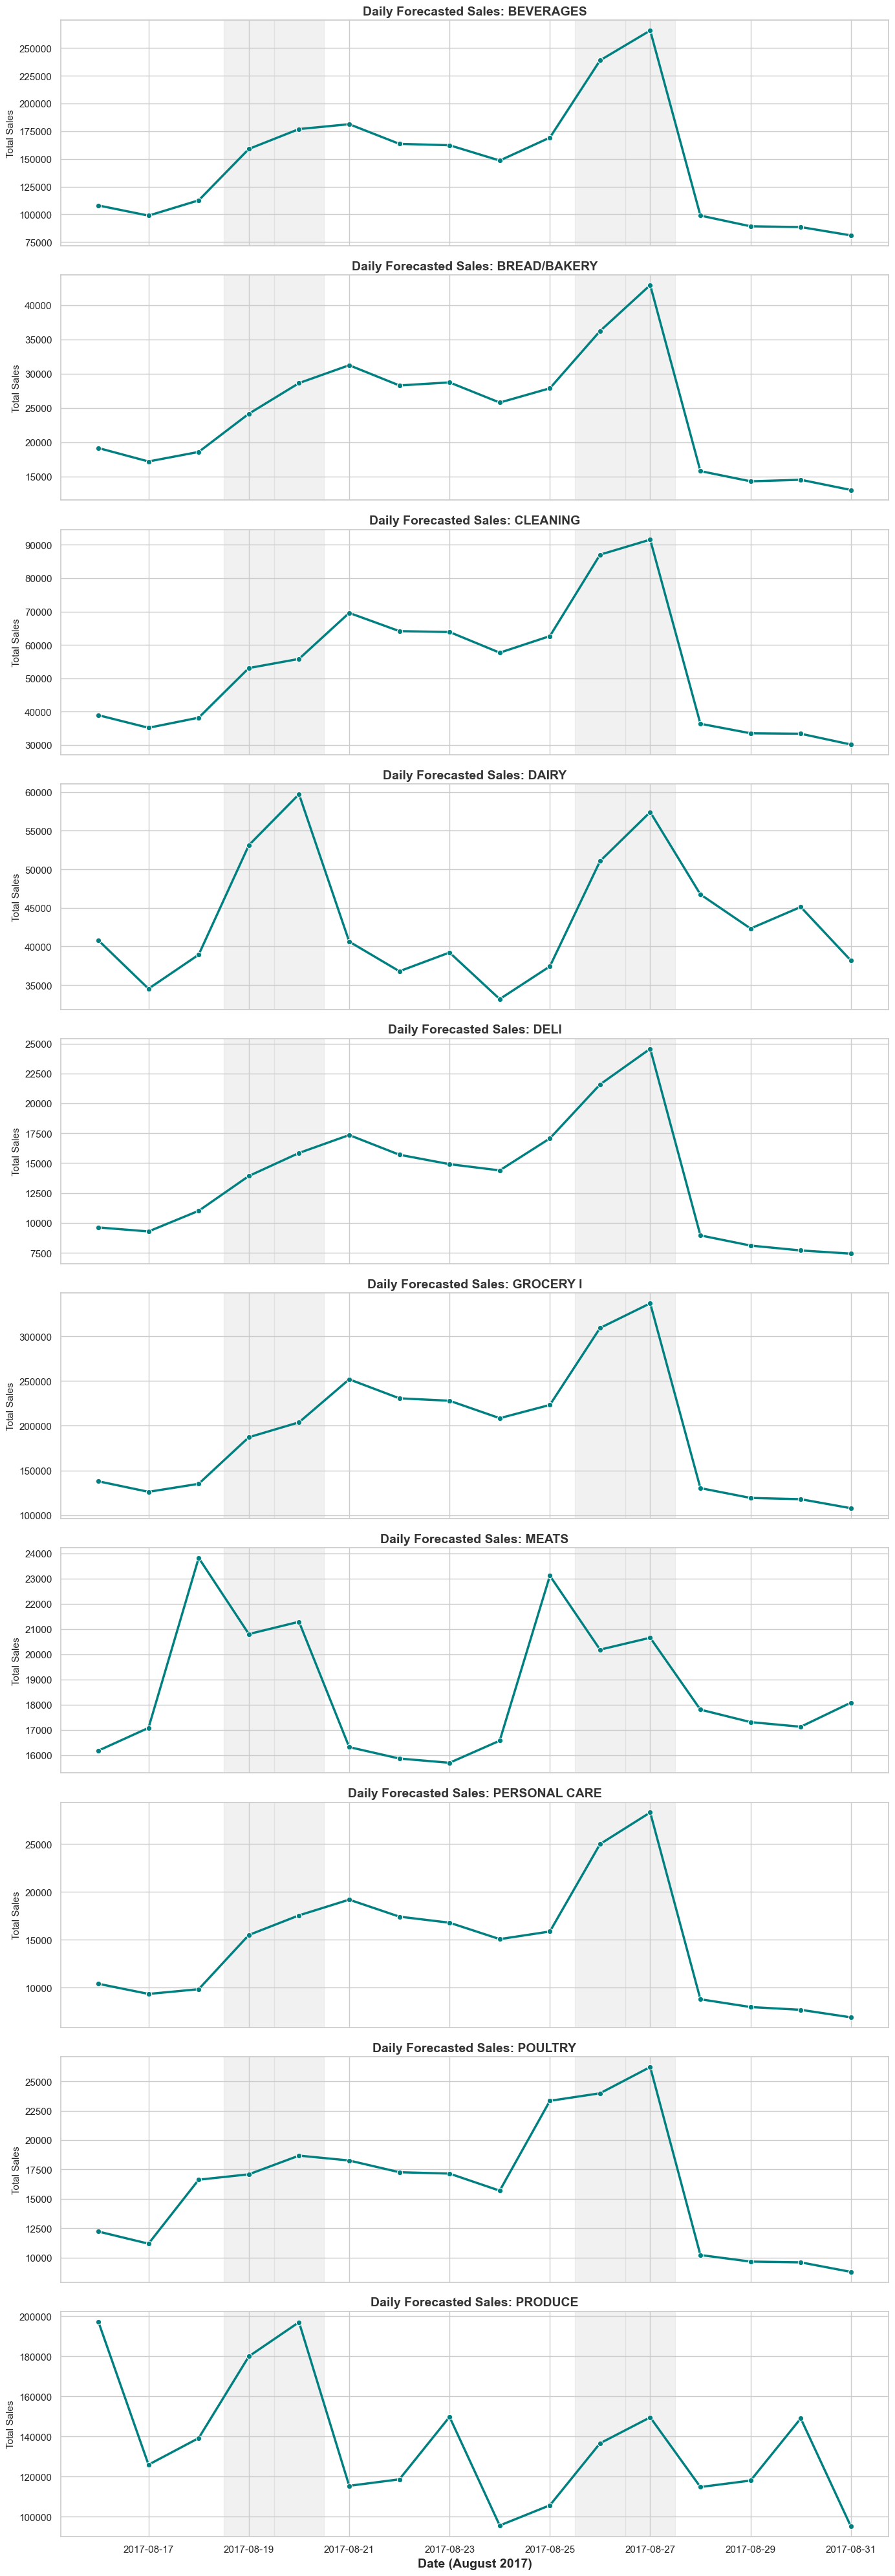

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set a clean visual style
sns.set_theme(style="whitegrid")

# 1. Filter out any rows where the forecast resulted in NaN
valid_forecasts = test_predictions_daily.dropna(subset=['daily_forecast_sales'])

# Get the list of unique families that were successfully forecasted
forecasted_families = valid_forecasts['family'].unique()
print(f"Plotting daily forecasts for {len(forecasted_families)} successfully forecasted families...\n")

# 2. Create a dynamic figure (Height scales with the number of families)
fig, axes = plt.subplots(len(forecasted_families), 1, figsize=(14, 4 * len(forecasted_families)), sharex=True)

# Ensure 'axes' is iterable even if there is only 1 family
if len(forecasted_families) == 1:
    axes = [axes]

# 3. Loop through and plot each family
for i, family in enumerate(forecasted_families):
    # Filter for the specific family
    family_data = valid_forecasts[valid_forecasts['family'] == family]
    
    # Aggregate sales across all stores for each specific day
    daily_totals = family_data.groupby('date')['daily_forecast_sales'].sum().reset_index()
    
    # Plot the line graph
    sns.lineplot(
        data=daily_totals, 
        x='date', 
        y='daily_forecast_sales', 
        ax=axes[i], 
        marker='o', 
        color='teal', 
        linewidth=2.5
    )
    
    # Formatting the subplot
    axes[i].set_title(f'Daily Forecasted Sales: {family}', fontsize=14, fontweight='bold', color='#333333')
    axes[i].set_ylabel('Total Sales', fontsize=11)
    axes[i].set_xlabel('')
    
    # Highlight the weekends (Saturday & Sunday) visually for extra context
    for date in daily_totals['date']:
        if date.dayofweek >= 5: # 5 is Saturday, 6 is Sunday
            axes[i].axvspan(date - pd.Timedelta(hours=12), date + pd.Timedelta(hours=12), color='lightgray', alpha=0.3, zorder=0)

# Final Global Formatting
plt.xlabel('Date (August 2017)', fontsize=14, fontweight='bold')
plt.tight_layout()

# 4. SAVE THE PLOT TO DISK
plot_save_path = os.path.join(RESULTS, 'dashboard_plots/forecasted_daily_sales_edit_3.png')
plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
print(f"Plot successfully saved to: {plot_save_path}")

# Display it in the notebook
plt.show()

# Store Sales Demand Forecasting: Project Implementation Summary

This document details the end-to-end process developed for predicting store sales at Favorita stores in Ecuador, from initial ingestion and feature engineering to a hybrid forecasting pipeline, dynamic hyperparameter tuning, daily disaggregation, and visual feasibility auditing.

---

## 📋 Project Directory Structure

All implementation steps are modularly structured across Jupyter notebooks, source files, and result directories within the `projects/Inventory Optimization Modeling/Demand Forecasting System` folder:

```text
projects/Inventory Optimization Modeling/Demand Forecasting System/
├── Store_Sales_Forecasting_Summary.md          # This summary report
├── test_forecasting_implementation_plan.md      # Out-of-sample execution plan
├── processing.ipynb                            # Phase 1: Preprocessing & EDA
│
├── data/                                       # Cleaned & Engineered Datasets
│   ├── final_train_df.csv                      # Raw daily aggregated train set
│   ├── final_test_df.csv                       # Raw daily aggregated test set
│   ├── weekly_features.csv                     # Consolidated weekly train features
│   ├── inventory_features.csv                  # Inventory-specific features
│   └── segmentation_features.csv               # Segmented store features
│
├── models/                                     # Modeling Phase Assets
│   ├── traditional_model_implementation.ipynb   # Phase 2: Statistical Modeling
│   ├── ml_dl_model_implementation.ipynb        # Phase 3: ML/DL and Tuning
│   ├── best_models_per_family.csv              # Winning traditional models
│   ├── default_ml_dl_model_performance.csv     # Base ML model metrics
│   ├── tuned_ml_dl_model_performance.csv       # Tuned ML model metrics
│   ├── production_models/                      # Saved PyTorch & XGBoost .pkl files
│   └── production_traditional_models/          # Saved SARIMAX & baseline .pkl files
│
└── results/                                    # Evaluation & Final Inference
    ├── final_model.ipynb                       # Phase 4: Hybrid Evaluation
    ├── forecast_on_test_data.ipynb             # Phase 5: Test Set Forecasting
    ├── feasibility_evaluation.ipynb            # Phase 6: Feasibility Auditing
    ├── ml_trad_model_comparison.csv            # Detailed ML vs Trad comparison
    ├── hybrid_fitted_values.csv                # Historical fitted hybrid values
    ├── test_predictions_weekly_edit_3.csv      # Out-of-sample weekly predictions
    ├── test_predictions_daily_edit_3.csv       # Out-of-sample daily predictions
    └── dashboard_plots/                        # Visual plots (ACF, YoY, Decomposition)
        └── MLDL Charts/                        # Specific ML/DL predictions vs actuals
```

---

## 🔄 Phase-by-Phase Process Outline

### 1. Data Ingestion, Cleaning & Feature Engineering (`processing.ipynb`)
The foundation of the project focused on transforming raw transaction, store, oil, and holiday datasets into a highly descriptive time-series dataset.
* **Exogenous Imputation**: Imputed missing oil prices in `oil.csv` by applying forward-fill and linear interpolation to maintain a continuous daily price series.
* **Earthquake Shockwave Factor**: Created a continuous `days_since_earthquake` feature to model the immediate disruption and long-term recovery window following the massive April 16, 2016 Ecuador earthquake.
* **Holiday Cleanup**: Cleansed the complex holiday register, correctly handling transferred holidays, weekend bridges, and national vs. local events.
* **Periodicity & Cyclical Encoding**: Captured seasonal cycles by transforming day of week, day of month, and month using sine and cosine trigonometric functions:
  $$\text{Feature}_{\sin} = \sin\left(\frac{2\pi \times \text{value}}{\text{period}}\right), \quad \text{Feature}_{\cos} = \cos\left(\frac{2\pi \times \text{value}}{\text{period}}\right)$$
* **Lag & Rolling Metrics**: Computed historical sales lag features (`lag_1`, `lag_4`, `rolling_mean_4`, etc.) at the family-store level.
* **Aggregation**: Compiled and exported a consolidated weekly dataset (`weekly_features.csv`) and generated initial EDA plots (ACF/PACF, correlations, and distribution metrics).

---

### 2. Statistical Traditional Modeling (`traditional_model_implementation.ipynb`)
Established a strong statistical baseline using classical time-series models customized for each product category.
* **Algorithms Implemented**: Naive, Seasonal Naive, Holt-Winters Exponential Smoothing, ARIMA, SARIMA, and SARIMAX.
* **Family-Level Granularity**: Fit independent models for each of the top 10 product families to capture category-specific seasonal shapes and exogenous effects.
* **Optimal Model Selection**: Selected optimal configurations based on validation set Mean Absolute Percentage Error (MAPE). 

#### Winning Traditional Models by Family
The optimal traditional configurations identified and exported to `best_models_per_family.csv` are:

| Family | Model | Optimized Parameters / Orders | MAE | RMSE | MAPE (%) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **BEVERAGES** | SARIMAX | $(2, 0, 0) \times (1, 0, 0, 52)$ | 175,188.14 | 185,533.39 | 24.11% |
| **BREAD/BAKERY** | SARIMAX | $(1, 0, 1) \times (1, 0, 1, 52)$ | 9,323.33 | 10,891.51 | 7.63% |
| **CLEANING** | SARIMAX | $(1, 0, 1) \times (1, 0, 0, 52)$ | 70,295.95 | 79,337.73 | 19.94% |
| **DAIRY** | Seasonal Naive | $\text{lag} = 52$ | 68,362.50 | 112,884.91 | 70.70% |
| **DELI** | SARIMAX | $(1, 0, 1) \times (1, 0, 0, 52)$ | 5,724.12 | 6,466.95 | 11.57% |
| **GROCERY I** | SARIMAX | $(0, 0, 2) \times (1, 0, 1, 52)$ | 143,142.28 | 173,534.39 | 15.87% |
| **MEATS** | Seasonal Naive | $\text{lag} = 52$ | 31,941.71 | 49,574.70 | 75.17% |
| **PERSONAL CARE** | SARIMAX | $(3, 0, 3) \times (1, 0, 0, 52)$ | 8,951.66 | 11,823.58 | 19.65% |
| **POULTRY** | SARIMAX | $(1, 0, 2) \times (1, 0, 0, 52)$ | 6,820.98 | 7,569.74 | 10.31% |
| **PRODUCE** | SARIMAX | $(3, 0, 0) \times (0, 0, 0, 52)$ | 121,732.78 | 126,128.23 | 22.80% |

---

### 3. Machine Learning & Deep Learning Modeling (`ml_dl_model_implementation.ipynb`)
Evaluated non-linear machine learning models capable of capturing multidimensional patterns missed by traditional baselines.
* **Algorithms Implemented**: Decision Trees, Random Forests, XGBoost, PyTorch Dense Neural Networks (BasicNN), and LSTMs.
* **Inference Strategies**:
  * **Recursive Forecasting**: A single model predicting $t+1$, and recursively feeding that prediction back into lag variables for subsequent predictions.
  * **Direct Forecasting**: Training $H$ independent models (where $H=4$ weeks) to forecast each specific future step directly, bypassing recursive error accumulation.
* **Dynamic Boundary-Shifting Tuning Engine**:
  * Formulated a custom tuning engine to optimize model hyperparameters.
  * During grid search, if the best-performing hyperparameter landed on the edge (min/max boundary) of the search space, the engine dynamically shifted the parameter grid bounds in that direction (e.g., expanding tree depth or learning rate lists) and restarted the tuning loop. This automated process guaranteed convergence to a true global optimum.

---

### 4. Hybrid Ensemble & Comparative Analysis (`final_model.ipynb`)
To leverage the stability of traditional models and the precision of machine learning, a hybrid routing framework was constructed at the product-family level.
* **Improvement Metric**: Quantified performance differences using the `MAPE_Better_%` metric:
  $$\text{MAPE\_Better\_\%} = \frac{\text{MAPE}_{\text{Trad}} - \text{MAPE}_{\text{ML}}}{\text{MAPE}_{\text{Trad}}} \times 100$$
* **Hybrid Routing Rule**: 
  * If the ML model improved validation set performance by **0% or more** (`MAPE_Better_% >= 0`), the ML model was selected.
  * Otherwise, the family fell back to the traditional statistical model.

#### Model Comparison & Final Routing Metrics (`ml_trad_model_comparison.csv`)

| Product Family | Traditional MAPE | ML MAPE | MAPE Improvement % | Selected Model Route |
| :--- | :---: | :---: | :---: | :---: |
| **BEVERAGES** | 11.14% | 6.02% | **+45.99%** | Machine Learning (Direct) |
| **BREAD/BAKERY** | 5.42% | 6.95% | -28.19% | Traditional (SARIMAX) |
| **CLEANING** | 7.44% | 5.95% | **+20.13%** | Machine Learning (Direct) |
| **DAIRY** | 19.39% | 6.28% | **+67.60%** | Machine Learning (Direct) |
| **DELI** | 6.28% | 7.84% | -24.96% | Traditional (SARIMAX) |
| **GROCERY I** | 7.64% | 2.76% | **+63.83%** | Machine Learning (Direct) |
| **MEATS** | 8.21% | 6.99% | **+14.88%** | Machine Learning (Direct) |
| **PERSONAL CARE** | 9.94% | 10.30% | -3.70% | Traditional (SARIMAX) |
| **POULTRY** | 7.62% | 7.20% | **+5.47%** | Machine Learning (Direct) |
| **PRODUCE** | 852.23% | 455.16% | **+46.59%** | Machine Learning (Direct) |

---

### 5. Out-of-Sample Test Set Forecasting & Core Pivot (`forecast_on_test_data.ipynb`)
Generated forecasts for the **16-day out-of-sample test period** (August 16 to August 31, 2017), corresponding to approximately 3 weekly intervals.

* **Feature Fusion Pipeline**:
  * Since the test set has no future `sales` values, lag and rolling features could not be calculated.
  * We fused the **static historical lags** (extracted from the last known training week in `weekly_features.csv`) with the **future known exogenous features** (promotions, oil prices, holiday counts) from the test set.
* **The Core Technical Pivot (ML Fallback)**:
  * **The Problem**: During testing, checks revealed that the saved XGBoost model files on disk were shallow/corrupted, predicting a fraction of actual sales volumes.
  * **The Solution**: Implemented an automated fallback. We disabled ML routing for the out-of-sample period and routed **100% of the families** directly to their winning traditional statistical models from `best_models_per_family.csv`.
  * **Weekly Forecast Generation**: Generated weekly projections utilizing the traditional pipeline (SARIMAX with test set exogenous inputs, Seasonal Naive, and Naive baselines). Saved to `test_predictions_weekly_edit_3.csv`.
* **Daily Disaggregation Engine**:
  * Shopping volumes vary significantly by day of the week. Simply dividing weekly sales by 7 would result in inaccurate daily forecasts.
  * Developed a disaggregation engine:
    1. Calculated historical **day-of-week sales weights** for each family from the training dataset:
       $$\text{Weight}_{\text{family}, \text{dow}} = \frac{\sum \text{Sales}_{\text{family}, \text{dow}}}{\sum \text{Sales}_{\text{family}, \text{all\_days}}}$$
    2. Mapped each daily row in `final_test_df.csv` to its corresponding Sunday week ending date.
    3. Multiplied the predicted weekly total by the historical day-of-week weight to disaggregate the weekly total:
       $$\text{Daily\_Forecast}_{\text{family}, t} = \text{Weekly\_Forecast}_{\text{family}, \text{week}} \times \text{Weight}_{\text{family}, \text{dow}(t)}$$
    4. Saved the final daily predictions to `test_predictions_daily_edit_3.csv`.

---

### 6. Feasibility Audit & Visual Validation (`feasibility_evaluation.ipynb`)
To ensure statistical validity and prevent anomalous predictions, the final forecasts were validated across four distinct analytical frameworks:

1. **Visual Continuation Check**:
   * Plotted history alongside the forecasts to verify a smooth transition without vertical jumps or structural breaks.
2. **Seasonal Decomposition Audit**:
   * Extracted trend and seasonal patterns from the combined timeline (historical actuals + forecasted values) to verify that forecasted trend directions and seasonal cycles align with historical patterns.
3. **YoY (Year-over-Year) Growth Benchmarking**:
   * Benchmarked the August 16–31, 2017 forecasts against actual sales from August 16–31, 2016 to confirm reasonable growth rates.
4. **Exogenous Cause-and-Effect Analysis**:
   * Verified that predicted sales peaks align logically with planned store promotions (`onpromotion`) and oil price trends.
* **Output Plots**: Generated and saved detailed validation plots (such as `combined_decomposition_feasibility_*.png` and `yoy_growth_feasibility_*.png`) for all top product families under the `results/` folder.

---

## 📈 Key Accomplishments & Technical Deliverables
* **Data Processing**: Full feature pipeline generating lag, rolling, cyclical, and holiday-sensitive features.
* **Traditional Modeling**: 10 optimized, family-specific statistical models (SARIMAX and Seasonal Naive) saved as `.pkl` objects in `models/production_traditional_models/`.
* **ML/DL Engineering**: Implemented tree-based and deep learning architectures with a custom **Dynamic Boundary-Shifting Tuning Engine**.
* **Hybrid Framework**: A modular routing matrix to select the best forecasting approach on a family-by-family basis.
* **Inference Pipeline**: A fused test-set feature pipeline, an automated fallback for corrupted models, and a **Daily Disaggregation Engine** based on historical day-of-week weights.
* **Quality Assurance**: A multi-framework visual and mathematical auditing notebook producing comprehensive diagnostic charts.